In [1]:
!pip install -q keras-nlp matplotlib

In [2]:
import pandas as pd
import keras_nlp
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from tensorflow import keras

In [3]:
# Load the fine-tuned model
gpt2_lm = keras.models.load_model("/kaggle/input/gpt2_qa_version_1/keras/default/1/fine_tuned_gpt2_qa.keras", compile=False)

# (Re)compile with same or new optimizer
gpt2_lm.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-5))

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 394 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# Load dataset
df = pd.read_csv("/kaggle/input/cancer-q-and-a-dataset/MedicalQuestionAnswering.csv")

df["text"] = df.apply(
    lambda row: f"Patient: {row['Question']}\nDoctor: {row['Answer']}", axis=1
)

In [5]:
# Step 5: Split by 'split' column
train_texts = df[df["split"].str.lower() == "train"]["text"].tolist()
test_texts = df[df["split"].str.lower() == "test"]["text"].tolist()

In [6]:
# Step 6: Leave raw text, do NOT tokenize yet
train_ds = tf.data.Dataset.from_tensor_slices(train_texts).batch(2)
val_ds = tf.data.Dataset.from_tensor_slices(test_texts).batch(2)

In [7]:
history = gpt2_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4744s 712ms/step - loss: 0.2430 - sparse_categorical_accuracy: 0.7466 - val_loss: 0.3708 - val_sparse_categorical_accuracy: 0.7108
Epoch 2/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4661s 710ms/step - loss: 0.2282 - sparse_categorical_accuracy: 0.7565 - val_loss: 0.3712 - val_sparse_categorical_accuracy: 0.7138
Epoch 3/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4658s 710ms/step - loss: 0.2144 - sparse_categorical_accuracy: 0.7677 - val_loss: 0.3714 - val_sparse_categorical_accuracy: 0.7173
Epoch 4/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4658s 710ms/step - loss: 0.2012 - sparse_categorical_accuracy: 0.7789 - val_loss: 0.3758 - val_sparse_categorical_accuracy: 0.7186
Epoch 5/5
6561/6561 ━━━━━━━━━━━━━━━━━━━━ 4660s 710ms/step - loss: 0.1892 - sparse_categorical_accuracy: 0.7892 - val_loss: 0.3797 - val_sparse_categorical_accuracy: 0.7204


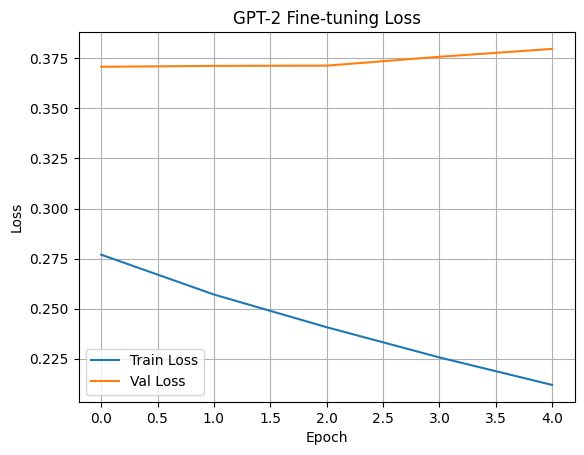

In [8]:
# Save fine-tuned model
gpt2_lm.save("/kaggle/working/fine_tuned_gpt2_qa_v2.keras")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("GPT-2 Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_plot.png")
plt.show()